In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os,re,glob

from scipy import stats
from scipy.interpolate import CubicSpline, UnivariateSpline
from sklearn.metrics import pairwise_distances
from scipy.stats import mannwhitneyu

from tqdm import tqdm
from pykalman import  KalmanFilter

In [2]:
def add_stat_annotation(ax, x1, x2, y, p_val, h):
    """
    ax: matplotlib の Axes オブジェクト
    x1, x2: 比較対象の箱（x座標；ここでは0と1と仮定）
    y: 横線の開始y座標
    p_val: 統計検定のp値
    h: オフセット（y軸方向）
    """
    color = 'black'
    # 横線の描画
    ax.plot([x1, x1, x2, x2],
            [y, y + h * 1.2, y + h * 1.2, y],
            color=color)
    # p値に応じたテキスト設定
    if p_val < 0.001:
        text = "***"
    elif p_val < 0.01:
        text = "**"
    elif p_val < 0.05:
        text = "*"
    else:
        text = "n.s."
    # 横線中央上部にテキストを描画
    ax.text((x1 + x2) * 0.5, y + h, text,
            ha='center', va='bottom', color=color, fontsize=20)



def create_kalman_filter(x, y):
    kf = KalmanFilter(initial_state_mean=[x, y, 0, 0],
                      transition_matrices=[[1, 0, 1, 0],
                                           [0, 1, 0, 1],
                                           [0, 0, 1, 0],
                                           [0, 0, 0, 1]],
                      observation_matrices=[[1, 0, 0, 0],
                                            [0, 1, 0, 0]],
                      transition_covariance=0.01 * np.eye(4),
                      observation_covariance=10.0 * np.eye(2),
                      initial_state_covariance=100.0 * np.eye(4))
    return kf


def smooth_trajectory(data, fps=10):
    data = data.copy()

    # 単体かどうかを判定
    is_single = 'ID' not in data.columns
    if is_single:
        data['ID'] = 0

    smoothed_data = []

    ids = data['ID'].unique()
    loop_iter = tqdm(ids, desc="Smoothing Trajectories") if len(ids) > 1 else ids
    for id_value in loop_iter:
        id_data = data[data['ID'] == id_value].sort_values(by='Frame')
        frames = id_data['Frame'].values
        observations = id_data[['Middle_X', 'Middle_Y']].interpolate(method='linear', limit_direction='both').values

        # カルマンフィルタの初期化
        kf = create_kalman_filter(observations[0, 0], observations[0, 1])
        state_means, _ = kf.smooth(observations)

        m = len(frames)
        k = min(3, max(1, m - 1))

        if k >= 1:
            smoothed_x = UnivariateSpline(frames, state_means[:, 0], k=k, s=2)(frames)
            smoothed_y = UnivariateSpline(frames, state_means[:, 1], k=k, s=2)(frames)
        else:
            smoothed_x = state_means[:, 0]
            smoothed_y = state_means[:, 1]

        id_data['Smoothed_X'] = smoothed_x
        id_data['Smoothed_Y'] = smoothed_y
        smoothed_data.append(id_data)

    result = pd.concat(smoothed_data).reset_index(drop=True)
    if is_single:
        result.drop(columns='ID', inplace=True)
    return result


def calculate_metrics(df, fps=10, x_col='Smoothed_X', y_col='Smoothed_Y', frame_col='Frame'):
    df = df.copy().sort_values(frame_col)

    frame_diff = np.diff(df[frame_col], prepend=np.nan)
    dt = frame_diff / fps

    dx = np.diff(df[x_col], prepend=np.nan)
    dy = np.diff(df[y_col], prepend=np.nan)
    distance = np.sqrt(dx**2 + dy**2)
    df['velocity [pixel/s]'] = distance / dt

    total_dist = np.nansum(distance[1:])
    start_end_dist = np.sqrt((df[x_col].iloc[-1] - df[x_col].iloc[0])**2 +
                             (df[y_col].iloc[-1] - df[y_col].iloc[0])**2)
    linearity = start_end_dist / total_dist if total_dist > 0 else np.nan

    angles = np.arctan2(np.diff(df[y_col]), np.diff(df[x_col]))
    angle_changes = np.abs(np.diff(angles, append=np.nan))
    angle_changes = np.where(angle_changes > np.pi, 2*np.pi - angle_changes, angle_changes)
    mean_angle_change = np.nanmean(angle_changes)

    return {
        'mean_velocity': np.nanmean(df['velocity [pixel/s]']),
        'linearity': linearity,
        'mean_angle_change': mean_angle_change
    }



In [3]:
control_single_dfs = glob.glob('../csvs/trajectory/C*L1.csv')
mutant_single_dfs = glob.glob('../csvs/trajectory/D*L1.csv')

control_group_dfs = glob.glob('../csvs/trajectory/C*overfit.csv')
mutant_group_dfs = glob.glob('../csvs/trajectory/D*overfit.csv')

<Axes: xlabel='Middle_X'>

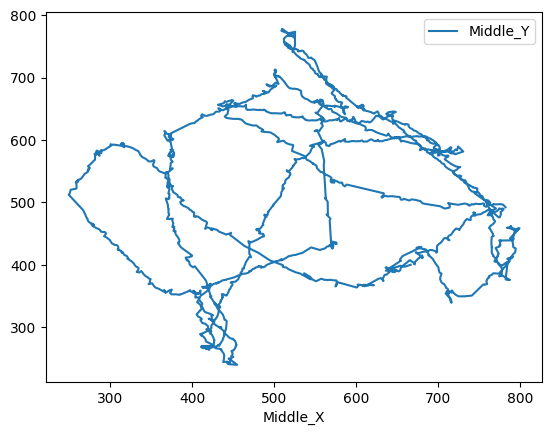

In [4]:
pd.read_csv(control_single_dfs[7]).plot(x = 'Middle_X', y = 'Middle_Y')

<Axes: xlabel='Smoothed_X'>

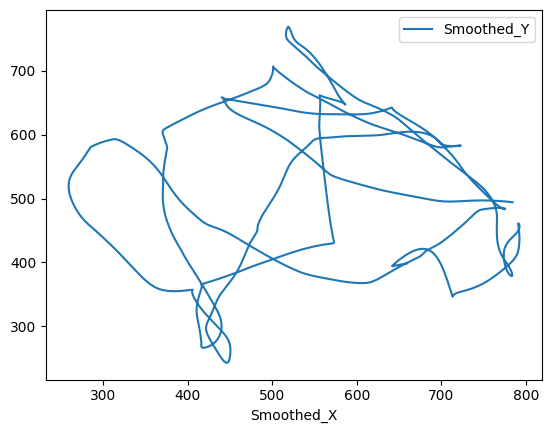

In [5]:
smooth_trajectory(pd.read_csv(control_single_dfs[7])).plot(x = 'Smoothed_X', y = 'Smoothed_Y')

In [11]:
pd.read_csv(control_single_dfs[7])

,Frame,ID,Head_X,Head_Y,Middle_X,Middle_Y,Tail_X,Tail_Y,Angle,DistMoved
0,4,1,672.59610,355.40323,666.57300,400.30795,620.51447,397.12546,86.313106,9.100342
1,5,1,663.56964,360.41876,660.33450,397.53635,623.33130,395.21524,88.607991,6.826493
2,6,1,674.55740,357.61563,657.28390,397.23776,614.78700,398.27878,65.041674,3.065176
3,7,1,673.25880,358.08040,655.41034,397.66916,611.90515,395.70303,68.319531,1.922560
4,8,1,673.25880,358.08040,655.41034,397.66916,611.90515,395.70303,68.319531,0.000000
...,...,...,...,...,...,...,...,...,...,...
2518,2991,1,829.45450,499.93842,777.34100,497.07834,728.00880,497.71620,3.882066,1.789694
2519,2992,1,831.04016,499.35820,779.51025,496.46246,730.38983,497.93375,4.932011,2.254983
2520,2993,1,833.14075,500.81268,782.40430,492.31448,730.97840,493.81842,11.183716,5.057788
2521,2994,1,833.14075,500.81268,782.40430,492.31448,730.97840,493.81842,11.183716,0.000000


<Axes: xlabel='Frame', ylabel='Middle_Y'>

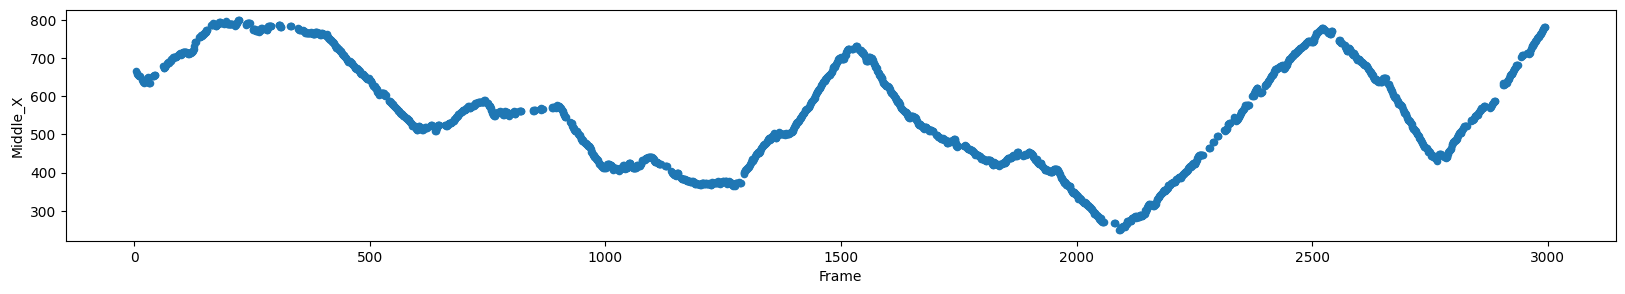

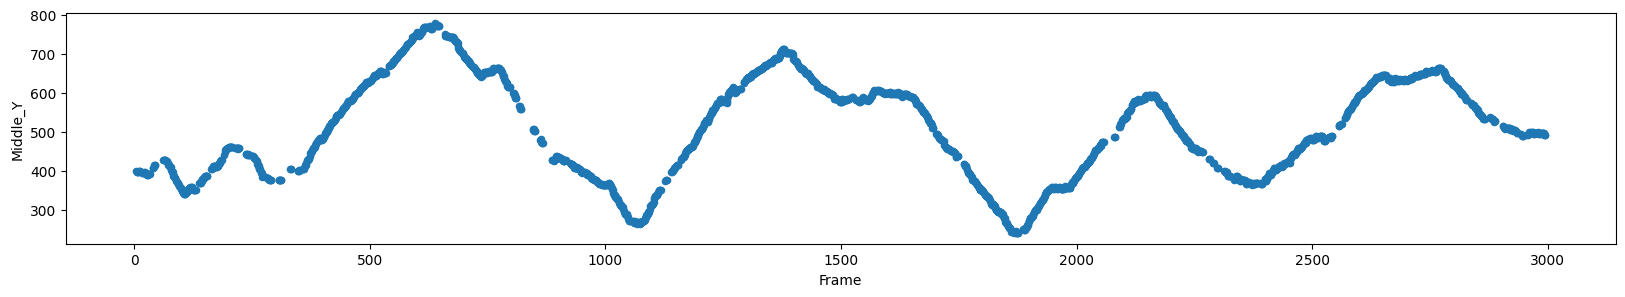

In [21]:
pd.read_csv(control_single_dfs[7]).plot.scatter(x = 'Frame', 
                                                y ='Middle_X',
                                               figsize=(20, 3))


pd.read_csv(control_single_dfs[7]).plot.scatter(x = 'Frame', 
                                                y ='Middle_Y',
                                                figsize=(20, 3))

# GPTによる　統計比較

DeepLabCutでは、出力された各フレームの座標列に対しメディアンフィルタ（移動窓幅5フレーム）を適用してノイズを低減することが推奨されています
。

またDeepLabCutではARIMAモデル（自己回帰移動平均）やスプライン補間によるフィルタリング機能も備わっており、時系列予測に基づいてブレをなめらかにすることもできます

In [ ]:
control_single_dfs = glob.glob('../csvs/trajectory/C*L1.csv')
mutant_single_dfs = glob.glob('../csvs/trajectory/D*L1.csv')

control_group_dfs = glob.glob('../csvs/trajectory/C*overfit.csv')
mutant_group_dfs = glob.glob('../csvs/trajectory/D*overfit.csv')

In [145]:
orco_single_dfs = glob.glob('../csvs/trajectory/o*L1.csv')
gr63_single_dfs = glob.glob('../csvs/trajectory/G*L1.csv')

In [54]:
from scipy.spatial import ConvexHull

In [213]:
def preprocess_trace_median_spline(df, median_kernel=5, filename = None):
    """
    ・Meta: df は ['frame','x','y','group','file'] を持つ
    ・median_kernel: メディアンフィルタの窓サイズ（奇数）
    
    1) frame でソート＆index化
    2) x,y にメディアンフィルタを適用 (x_med, y_med)
    3) 欠損フレームを含む full_frames = [min_frame…max_frame]
    4) valid なフレームで CubicSpline をフィッティング
    5) full_frames 全体にスプライン補間して x_interp,y_interp を得る
    6) group, file 情報を復元して返却
    """
    # 1) ソートして frame を index
    df2 = df.sort_values("Frame").set_index("Frame")
    
    # 2) メディアン平滑化
    df2["x_med"] = medfilt(df2["Middle_X"], kernel_size=median_kernel)
    df2["y_med"] = medfilt(df2["Middle_Y"], kernel_size=median_kernel)
    
    # 3) 補完用のフレーム番号リスト
    start, end = df2.index.min(), df2.index.max()
    full_frames = np.arange(start, end + 1)
    
    # 4) スプラインに使う有効フレーム
    valid = df2.index[df2["x_med"].notna() & df2["y_med"].notna()]
    if len(valid) < 2:
        # 補完できない場合はメディアン値だけ返す
        out = pd.DataFrame({
            "frame": full_frames,
            "x_interp": np.repeat(df2["x_med"].iloc[0], len(full_frames)),
            "y_interp": np.repeat(df2["y_med"].iloc[0], len(full_frames))
        })
    else:
        # 5) CubicSpline で全フレームを補完
        cs_x = CubicSpline(valid, df2.loc[valid, "x_med"])
        cs_y = CubicSpline(valid, df2.loc[valid, "y_med"])
        x_interp = cs_x(full_frames)
        y_interp = cs_y(full_frames)
        
        out = pd.DataFrame({
            "frame": full_frames,
            "x_interp": x_interp,
            "y_interp": y_interp
        })

    if filename is not None:
        out['filename'] = filename
    
    return df, df2, out


def extract_features(df, filename = None, fps = 10, pixel2cm = 0.0045):
    """
    df: 前処理済みの DataFrame。必ず x_interp, y_interp があること。
    戻り値: 各個体（file）ごとの特徴量 Series
    """
    # フレーム間移動量（frameごとの距離）
    dx = np.diff(df["x_interp"], prepend=np.nan)
    dy = np.diff(df["y_interp"], prepend=np.nan)
    dist = np.sqrt(dx**2 + dy**2)

    # Convert to speed (distance per second)
    speed = dist * fps * pixel2cm
    
    # 基本指標
    total_dist    = np.nansum(dist)                          # 累積距離
    displacement  = np.hypot(df["x_interp"].iloc[-1] - df["x_interp"].iloc[0],
                             df["y_interp"].iloc[-1] - df["y_interp"].iloc[0])  # 始点→終点の直線距離

    # Speed metrics
    mean_speed    = np.nanmean(speed)
    median_speed  = np.nanmedian(speed)
    max_speed     = np.nanmax(speed)
    speed_std     = np.nanstd(speed)
    
    # Tortuosity: straightness = displacement / total_distance
    tortuosity = displacement / total_dist if total_dist > 0 else np.nan
    
    # Occupancy area (convex hull)
    try:
        pts = np.vstack([df["x_interp"], df["y_interp"]]).T
        hull = ConvexHull(pts)
        area = hull.volume  # 2D volume is area
    except:
        area = np.nan

    if 'C' in filename:
        group = '$white^{1118}$'
    elif 'mel' in filename:
        group = 'willistoni'
    elif 'D' in filename:
        group = '$orco^2$, $Gr63a$'
    elif 'o' in filename:
        group = '$orco^2$'
    elif 'G' in filename:
        group = '$Gr63a$'
    
    
    # 辞書から1行のDataFrameを作成
    data = {
        "filename":    filename,
        "group": group,
        "total_dist [cm]":   total_dist,
        "displacement": displacement,
        "area":         area,
        "mean_speed [cm/s]":   mean_speed,
        "median_speed [cm/s]": median_speed,
        "max_speed [cm/s]":    max_speed,
        "speed_std [cm/s]":    speed_std,
        "tortuosity":   tortuosity
    }
    return pd.DataFrame([data])


In [214]:
group_pixel = 0.006
single_pixel = 0.0045

control_single_df = pd.DataFrame()
control_single_results = pd.DataFrame()
for pathname in tqdm(control_single_dfs):
    filename = os.path.splitext(os.path.basename(pathname))[0]
    df = pd.read_csv(pathname)
    for ID_ in df['ID'].unique():
        df_ext = df[df['ID'] == ID_]
        _,_,pro_df = preprocess_trace_median_spline(df_ext, median_kernel=5, filename=filename)
        results = extract_features(pro_df, filename = filename, fps = 10, pixel2cm=single_pixel)
        control_single_df = pd.concat([control_single_df, pro_df])
        control_single_results = pd.concat([control_single_results, results])


mutant_single_df = pd.DataFrame()
mutant_single_results = pd.DataFrame()
for pathname in tqdm(mutant_single_dfs):
    filename = os.path.splitext(os.path.basename(pathname))[0]
    df = pd.read_csv(pathname)
    for ID_ in df['ID'].unique():
        df_ext = df[df['ID'] == ID_]
        _,_,pro_df = preprocess_trace_median_spline(df_ext, median_kernel=5, filename=filename)
        results = extract_features(pro_df, filename = filename, fps = 10, pixel2cm=single_pixel)
        mutant_single_df = pd.concat([mutant_single_df, pro_df])
        mutant_single_results = pd.concat([mutant_single_results, results])

control_group_df = pd.DataFrame()
control_group_results = pd.DataFrame()
for pathname in tqdm(control_group_dfs):
    filename = os.path.splitext(os.path.basename(pathname))[0]
    df = pd.read_csv(pathname)
    for ID_ in df['ID'].unique():
        df_ext = df[df['ID'] == ID_]
        _,_,pro_df = preprocess_trace_median_spline(df_ext, median_kernel=5, filename=filename)
        results = extract_features(pro_df, filename = filename, fps = 10, pixel2cm=single_pixel)
        control_group_df = pd.concat([control_group_df, pro_df])
        control_group_results = pd.concat([control_group_results, results])


mutant_group_df = pd.DataFrame()
mutant_group_results = pd.DataFrame()
for pathname in tqdm(mutant_group_dfs):
    filename = os.path.splitext(os.path.basename(pathname))[0]
    df = pd.read_csv(pathname)
    for ID_ in df['ID'].unique():
        df_ext = df[df['ID'] == ID_]
        _,_,pro_df = preprocess_trace_median_spline(df_ext, median_kernel=5, filename=filename)
        results = extract_features(pro_df, filename = filename, fps = 10, pixel2cm=single_pixel)
        mutant_group_df = pd.concat([mutant_group_df, pro_df])
        mutant_group_results = pd.concat([mutant_group_results, results])



orco_single_df = pd.DataFrame()
orco_single_results = pd.DataFrame()
for pathname in tqdm(orco_single_dfs):
    filename = os.path.splitext(os.path.basename(pathname))[0]
    df = pd.read_csv(pathname)
    for ID_ in df['ID'].unique():
        df_ext = df[df['ID'] == ID_]
        _,_,pro_df = preprocess_trace_median_spline(df_ext, median_kernel=5, filename=filename)
        results = extract_features(pro_df, filename = filename, fps = 10, pixel2cm=single_pixel)
        orco_single_df = pd.concat([orco_single_df, pro_df])
        orco_single_results = pd.concat([orco_single_results, results])


gr63_single_df = pd.DataFrame()
gr63_single_results = pd.DataFrame()
for pathname in tqdm(gr63_single_dfs):
    filename = os.path.splitext(os.path.basename(pathname))[0]
    df = pd.read_csv(pathname)
    for ID_ in df['ID'].unique():
        df_ext = df[df['ID'] == ID_]
        _,_,pro_df = preprocess_trace_median_spline(df_ext, median_kernel=5, filename=filename)
        results = extract_features(pro_df, filename = filename, fps = 10, pixel2cm=single_pixel)
        gr63_single_df = pd.concat([gr63_single_df, pro_df])
        gr63_single_results = pd.concat([gr63_single_results, results])

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 150.66it/s]


## 検定 t-検定

In [162]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu
from statsmodels.stats.anova import AnovaRM

def run_feature_tests(ctrl_df, mut_df, feature_cols, alpha=0.05):
    """
    各特徴量についてControl vs Mutantの比較検定を実行
    - Shapiro-Wilk検定で正規性を評価
    - Levene検定で等分散性を評価
    - 正規性かつ等分散ならWelchのt検定、非正規または等分散性違反ならMann-Whitney U検定
    """
    results = []
    for feat in feature_cols:
        x = ctrl_df[feat].dropna()
        y = mut_df[feat].dropna()
        # 正規性
        _, p_norm_x = shapiro(x) if len(x) >= 3 else (np.nan, np.nan)
        _, p_norm_y = shapiro(y) if len(y) >= 3 else (np.nan, np.nan)
        # 等分散性
        _, p_levene = levene(x, y)
        # 検定選択
        if p_norm_x > alpha and p_norm_y > alpha and p_levene > alpha:
            stat, p_val = ttest_ind(x, y, equal_var=False)
            test_name = "Welch t-test"
        else:
            stat, p_val = mannwhitneyu(x, y, alternative="two-sided")
            test_name = "Mann-Whitney U"
        results.append({
            "feature": feat,
            "normal_p_ctrl": p_norm_x,
            "normal_p_mut": p_norm_y,
            "levene_p": p_levene,
            "test": test_name,
            "statistic": stat,
            "p_value": p_val
        })
    return pd.DataFrame(results)

# 比較したい特徴量リスト
feature_columns = ["mean_speed [cm/s]", "area"]


# Control 個体間比較（single）
single_results = run_feature_tests(control_single_results, mutant_single_results, feature_columns)

# Control 個体間比較（group）
group_results  = run_feature_tests(control_group_results, mutant_group_results, feature_columns)



/tmp/ipykernel_100/3829724497.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y=metric, data=all_results, palette="coolwarm", ax=ax, showfliers=False)
/tmp/ipykernel_100/3829724497.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='group', y=metric, data=all_results, palette='coolwarm', linewidth=2, size=20, jitter=True, ax=ax)
/tmp/ipykernel_100/3829724497.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y=metric, data=all_results, palette="coolwarm", ax=ax, showfliers=False)
/tmp/ipykernel_100/38297244

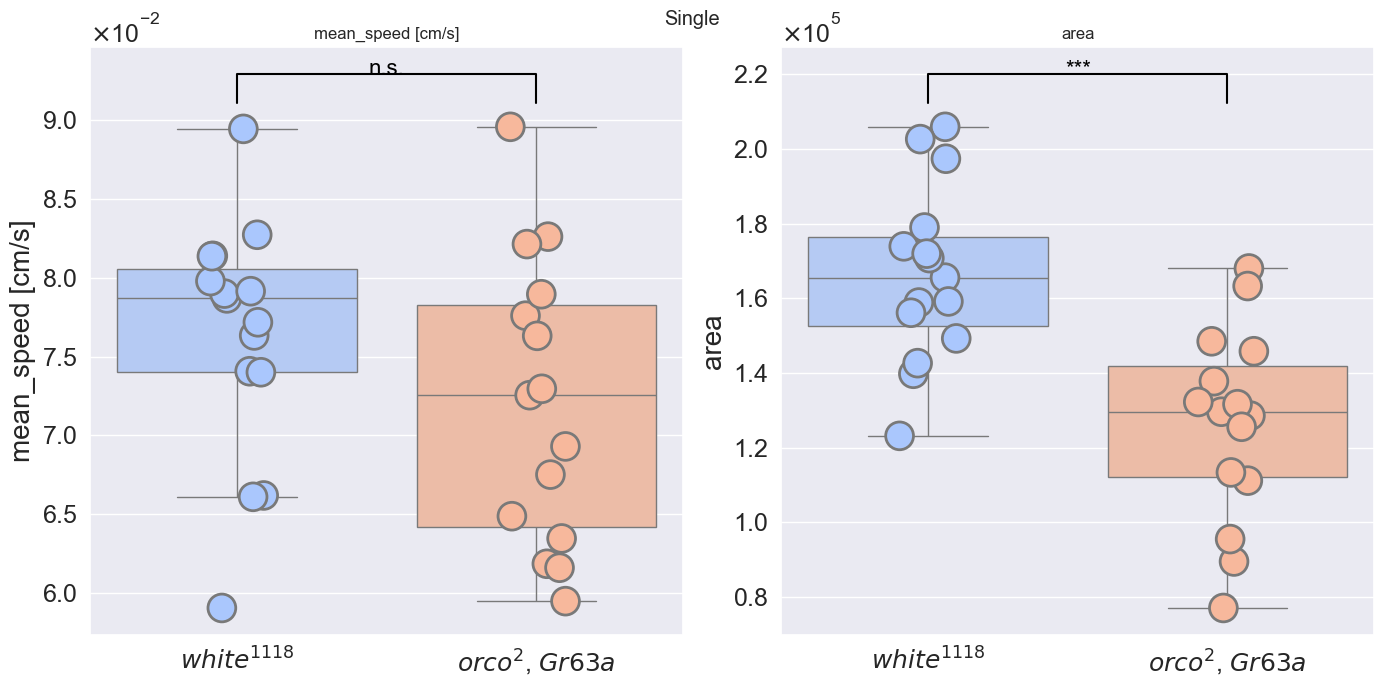

In [209]:
from scipy.stats import mannwhitneyu
import matplotlib.ticker as ticker

# control_single_df と mutant_single_df を統合
all_results = pd.concat([control_single_results, mutant_single_results], ignore_index=True)

# 可視化したい指標リスト
metrics = feature_columns  # 例: ["total_dist", "mean_speed", "median_speed", "max_speed", "tortuosity"]

def add_stat_annotation(ax, x1, x2, y, p_val, h):
    """
    ax: matplotlib の Axes オブジェクト
    x1, x2: 比較対象の箱の x 座標
    y: 横線の開始 y 座標
    p_val: 統計検定の p 値
    h: y 軸方向のオフセット
    """
    color = 'black'
    # 横線の描画
    ax.plot([x1, x1, x2, x2],
            [y, y + h*1.2, y + h*1.2, y],
            color=color)
    # p 値に応じたアノテーション
    if p_val < 0.001:
        text = "***"
    elif p_val < 0.01:
        text = "**"
    elif p_val < 0.05:
        text = "*"
    else:
        text = "n.s."
    # テキスト描画
    ax.text((x1 + x2) * 0.5, y + h, text,
            ha='center', va='bottom', color=color, fontsize=16)

# プロットの作成
fig, axes = plt.subplots(1, len(metrics), figsize=(7 * len(metrics), 7), squeeze=False)

for i, metric in enumerate(metrics):
    ax = axes[0, i]
    sns.boxplot(x='group', y=metric, data=all_results, palette="coolwarm", ax=ax, showfliers=False)
    sns.stripplot(x='group', y=metric, data=all_results, palette='coolwarm', linewidth=2, size=20, jitter=True, ax=ax)
    ax.set_title(metric)

    # ScalarFormatter を設定して指数表記にする
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))  # 常に指数表記にする
    ax.yaxis.set_major_formatter(formatter)
    ax.tick_params(axis='x', labelsize=18)
    ax.tick_params(axis='y', labelsize=18)
    ax.set_ylabel(metric, fontsize=20)  # ← フォントサイズ指定
    ax.set_xlabel('')
    
    
    # offset 表記（例：×10⁻²）を見やすく調整
    ax.yaxis.offsetText.set_fontsize(18)

    # p 値計算 (Control vs Mutant)
    ctrl_vals = all_results.loc[all_results['group'] == '$white^{1118}$', metric].dropna()
    mut_vals  = all_results.loc[all_results['group'] == '$orco^2$, $Gr63a$', metric].dropna()
    stat, p_val = mannwhitneyu(ctrl_vals, mut_vals, alternative='two-sided')

    # アノテーション用座標計算
    y_max = all_results[metric].max()
    y_min = all_results[metric].min()
    h_offset = (y_max - y_min) * 0.05

    add_stat_annotation(ax, 0, 1, y_max + h_offset, p_val, h_offset)

plt.tight_layout()
plt.suptitle("Single")
plt.show()

/tmp/ipykernel_100/2198739647.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y=metric, data=all_results, palette="coolwarm", ax=ax, showfliers=False)
/tmp/ipykernel_100/2198739647.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='group', y=metric, data=all_results, palette='coolwarm', linewidth=2, size=20, jitter=True, ax=ax)
/tmp/ipykernel_100/2198739647.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y=metric, data=all_results, palette="coolwarm", ax=ax, showfliers=False)
/tmp/ipykernel_100/21987396

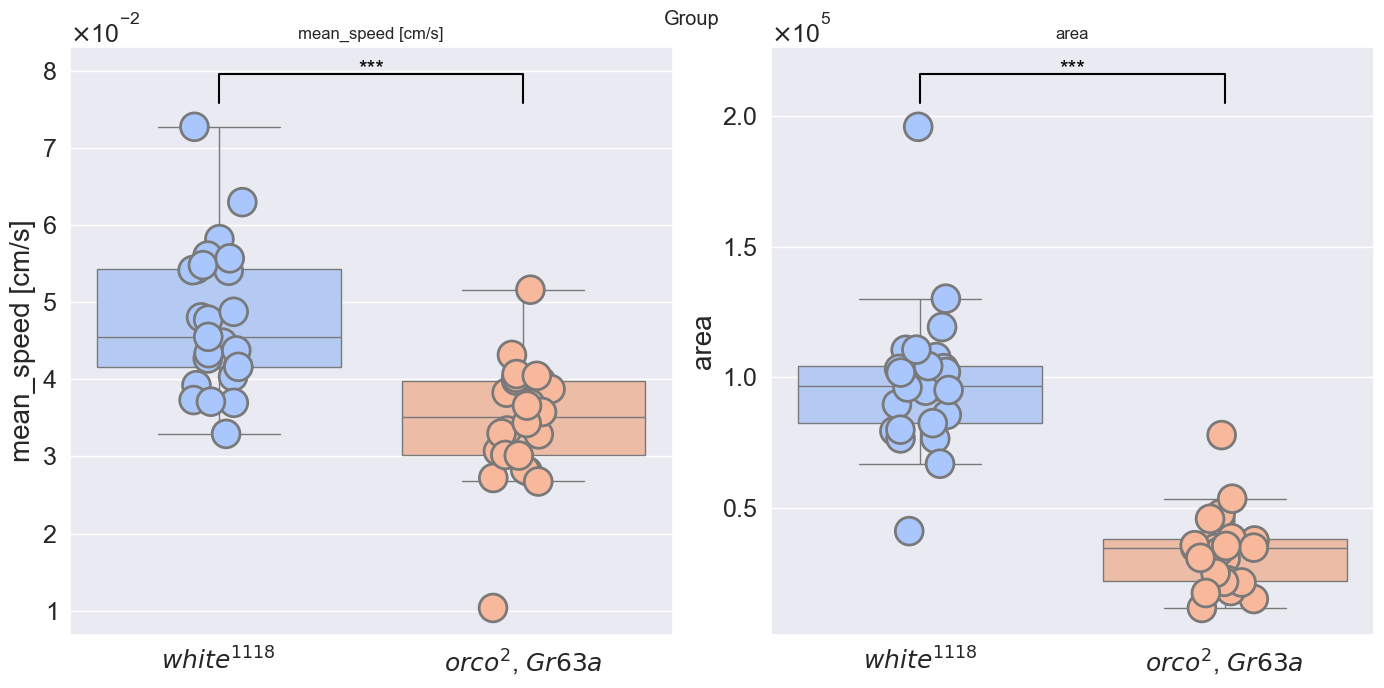

In [210]:
from scipy.stats import mannwhitneyu

# control_single_df と mutant_single_df を統合
all_results = pd.concat([control_group_results, mutant_group_results], ignore_index=True)

# 可視化したい指標リスト
metrics = feature_columns  # 例: ["total_dist", "mean_speed", "median_speed", "max_speed", "tortuosity"]

def add_stat_annotation(ax, x1, x2, y, p_val, h):
    """
    ax: matplotlib の Axes オブジェクト
    x1, x2: 比較対象の箱の x 座標
    y: 横線の開始 y 座標
    p_val: 統計検定の p 値
    h: y 軸方向のオフセット
    """
    color = 'black'
    # 横線の描画
    ax.plot([x1, x1, x2, x2],
            [y, y + h*1.2, y + h*1.2, y],
            color=color)
    # p 値に応じたアノテーション
    if p_val < 0.001:
        text = "***"
    elif p_val < 0.01:
        text = "**"
    elif p_val < 0.05:
        text = "*"
    else:
        text = "n.s."
    # テキスト描画
    ax.text((x1 + x2) * 0.5, y + h, text,
            ha='center', va='bottom', color=color, fontsize=16)

# プロットの作成
fig, axes = plt.subplots(1, len(metrics), figsize=(7 * len(metrics), 7), squeeze=False)

for i, metric in enumerate(metrics):
    ax = axes[0, i]
    sns.boxplot(x='group', y=metric, data=all_results, palette="coolwarm", ax=ax, showfliers=False)
    sns.stripplot(x='group', y=metric, data=all_results, palette='coolwarm', linewidth=2, size=20, jitter=True, ax=ax)
    ax.set_title(metric)

    # ScalarFormatter を設定して指数表記にする
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))  # 常に指数表記にする
    ax.yaxis.set_major_formatter(formatter)
    ax.tick_params(axis='x', labelsize=18)
    ax.tick_params(axis='y', labelsize=18)
    ax.set_ylabel(metric, fontsize=20)  # ← フォントサイズ指定
    ax.set_xlabel('')
    
    # offset 表記（例：×10⁻²）を見やすく調整
    ax.yaxis.offsetText.set_fontsize(18)

    # p 値計算 (Control vs Mutant)
    ctrl_vals = all_results.loc[all_results['group'] == '$white^{1118}$', metric].dropna()
    mut_vals  = all_results.loc[all_results['group'] == '$orco^2$, $Gr63a$', metric].dropna()
    stat, p_val = mannwhitneyu(ctrl_vals, mut_vals, alternative='two-sided')

    # アノテーション用座標計算
    y_max = all_results[metric].max()
    y_min = all_results[metric].min()
    h_offset = (y_max - y_min) * 0.05

    add_stat_annotation(ax, 0, 1, y_max + h_offset, p_val, h_offset)

plt.tight_layout()
plt.suptitle("Group")
plt.show()

## 変異体の数ごと

/tmp/ipykernel_100/2403284491.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y=metric, data=subset, palette="coolwarm", ax=ax, showfliers=False)
/tmp/ipykernel_100/2403284491.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='group', y=metric, data=subset, palette='coolwarm', linewidth=2, size=20, jitter=True, ax=ax)
/tmp/ipykernel_100/2403284491.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y=metric, data=subset, palette="coolwarm", ax=ax, showfliers=False)
/tmp/ipykernel_100/2403284491.py:29: Futur

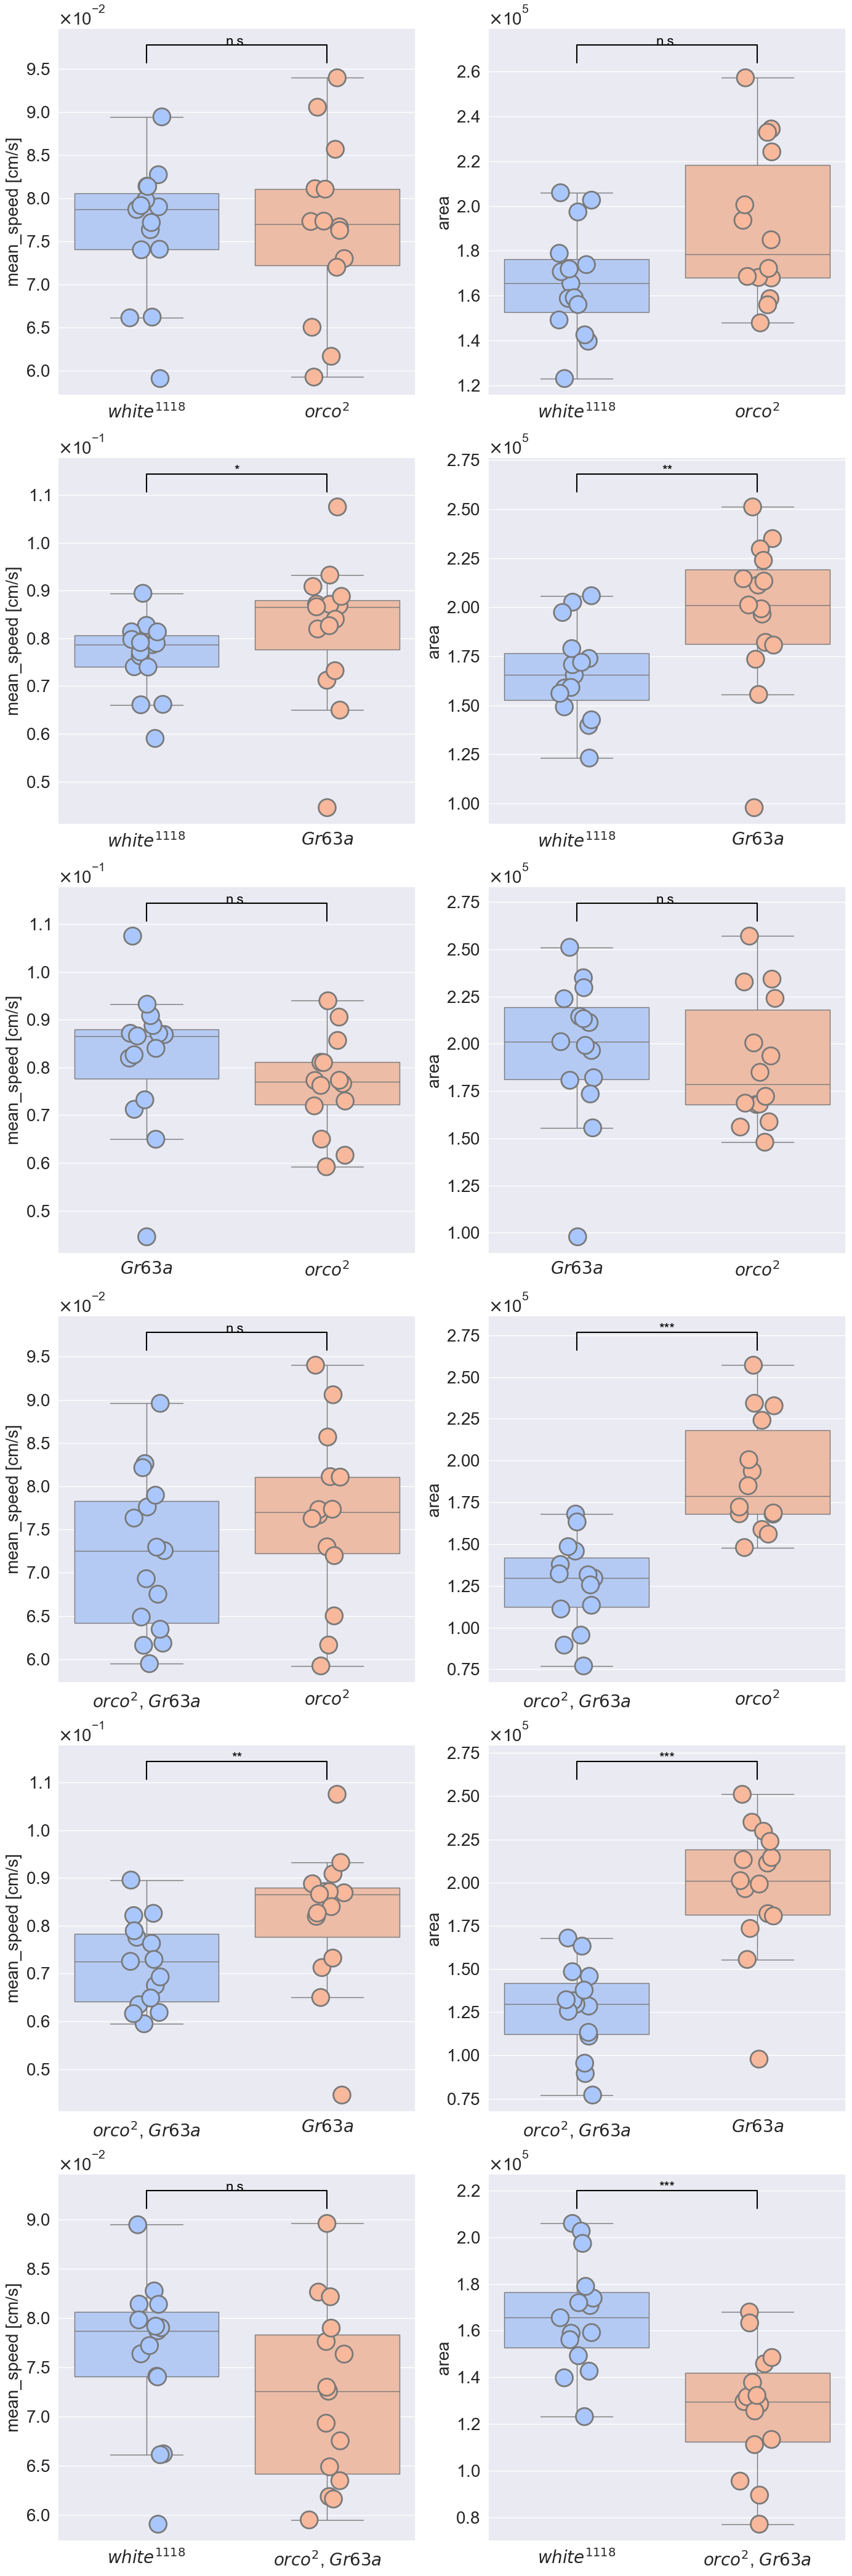

In [211]:
from scipy.stats import mannwhitneyu

# control_single_df と mutant_single_df を統合
all_results = pd.concat([control_single_results, mutant_single_results, gr63_single_results, orco_single_results], ignore_index=True)

# 可視化したい指標リスト
metrics = feature_columns  # 例: ["total_dist", "mean_speed", "median_speed", "max_speed", "tortuosity"]



comparisons = [
    ("$white^{1118}$", "$orco^2$"),
    ("$white^{1118}$", "$Gr63a$"),
    ("$orco^2$", "$Gr63a$"),
    ("$orco^2$", "$orco^2$, $Gr63a$"),
    ("$Gr63a$", "$orco^2$, $Gr63a$"),
    ("$white^{1118}$", "$orco^2$, $Gr63a$")  # 既存
]

fig, axes = plt.subplots(len(comparisons), len(metrics), figsize=(7 * len(metrics), 7 * len(comparisons)), squeeze=False)

for row_idx, (ctrl_group, mut_group) in enumerate(comparisons):
    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        # 対象グループのみ抽出
        subset = all_results[all_results['group'].isin([ctrl_group, mut_group])]

        sns.boxplot(x='group', y=metric, data=subset, palette="coolwarm", ax=ax, showfliers=False)
        sns.stripplot(x='group', y=metric, data=subset, palette='coolwarm', linewidth=2, size=20, jitter=True, ax=ax)


        # 軸フォーマット
        formatter = ticker.ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((0, 0))
        ax.yaxis.set_major_formatter(formatter)
        ax.yaxis.offsetText.set_fontsize(20)
        ax.tick_params(axis='x', labelsize=20)
        ax.tick_params(axis='y', labelsize=20)
        ax.set_ylabel(metric, fontsize=20)  # ← フォントサイズ指定
        ax.set_xlabel('', fontsize=20)

        # p値計算とアノテーション
        ctrl_vals = subset[subset['group'] == ctrl_group][metric].dropna()
        mut_vals  = subset[subset['group'] == mut_group][metric].dropna()
        stat, p_val = mannwhitneyu(ctrl_vals, mut_vals, alternative='two-sided')
        y_max = subset[metric].max()
        y_min = subset[metric].min()
        h_offset = (y_max - y_min) * 0.05
        add_stat_annotation(ax, 0, 1, y_max + h_offset, p_val, h_offset)

plt.tight_layout()
#plt.suptitle("Single comparisons", fontsize=20)
plt.show()

# ANOVA

In [169]:
import pandas as pd

# 各DataFrameに group, condition 列を追加
def add_labels(df, strain, condition):
    df = df.copy()
    df["strain"] = strain
    df["condition"] = condition
    return df

dfs = [
    add_labels(control_single_results, "control", "single"),
    add_labels(control_group_results, "control", "group"),
    add_labels(orco_single_results, "orco", "single"),
    add_labels(gr63_single_results, "gr63", "single"),
    add_labels(mutant_single_results, "mutant", "single"),
    add_labels(mutant_group_results, "mutant", "group")
]

all_df = pd.concat(dfs, ignore_index=True)


In [172]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Q() で特殊文字を含むカラム名を囲む
model = ols('Q("mean_speed [cm/s]") ~ C(strain) * C(condition)', data=all_df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)


                          sum_sq     df           F        PR(>F)
C(strain)               0.003496    3.0   12.275943  1.670741e-05
C(condition)            0.027629    1.0  291.022651  1.212499e-31
C(strain):C(condition)  0.000610    3.0    2.142263  9.950524e-02
Residual                0.009684  102.0         NaN           NaN


/opt/conda/lib/python3.10/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '


In [173]:
# Tukeyの例（group列を使って）
all_df["group"] = all_df["strain"] + "_" + all_df["condition"]

from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(endog=all_df["mean_speed [cm/s]"], groups=all_df["group"], alpha=0.05)
print(tukey)

        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------
 control_group control_single   0.0285    0.0  0.0193  0.0378   True
 control_group    gr63_single   0.0343    0.0   0.025  0.0435   True
 control_group   mutant_group  -0.0133 0.0001 -0.0214 -0.0052   True
 control_group  mutant_single   0.0243    0.0   0.015  0.0335   True
 control_group    orco_single   0.0287    0.0  0.0193  0.0381   True
control_single    gr63_single   0.0058 0.5859 -0.0046  0.0161  False
control_single   mutant_group  -0.0418    0.0 -0.0512 -0.0325   True
control_single  mutant_single  -0.0042 0.8387 -0.0146  0.0061  False
control_single    orco_single   0.0002    1.0 -0.0103  0.0107  False
   gr63_single   mutant_group  -0.0476    0.0 -0.0569 -0.0383   True
   gr63_single  mutant_single    -0.01 0.0629 -0.0204  0.0003  False
   gr63_single    orco_single  -0.

### 結果の解釈

とても良い結果が得られています。
以下に **ANOVA** と **Tukeyの多重比較** の結果を、研究解釈に即してわかりやすく解説します。

---

## ✅ 1. **二要因 ANOVA の解釈**

| 効果                           | p値（PR(>F)）      | 解釈                 |
| ---------------------------- | --------------- | ------------------ |
| **変異の主効果（strain）**           | 1.67e-05（有意）    | 変異の種類によって速度が異なる    |
| **行動条件の主効果（condition）**      | 1.21e-31（非常に有意） | 単独か集団かで速度が大きく異なる   |
| **交互作用（strain × condition）** | 0.0995（有意でない）   | 変異の影響は条件によらず安定している |

### 🔍 要約：

* **変異の種類も、単独か集団かも、それぞれ速度に大きな影響がある**
* ただし、「変異による影響が単独と集団で異なる」という **交互作用は認められなかった**

---

## ✅ 2. **Tukeyの多重比較：どの群とどの群で差があるか**

比較対象をいくつかのカテゴリに整理して説明します：

---

### ▶️ **control\_group vs 他の群**

| 群比較                               | 有意差あり？ | 解釈例                    |
| --------------------------------- | ------ | ---------------------- |
| control\_group vs control\_single | ✅ True | **集団のほうが速い**（0.0285の差） |
| control\_group vs mutant\_group   | ✅ True | **変異体の集団は遅くなっている**     |
| control\_group vs orco\_single    | ✅ True | **orco単独変異も遅くなっている**   |
| control\_group vs gr63\_single    | ✅ True | **gr63単独変異も遅くなっている**   |

→ **コントロール集団**は、ほとんどの群よりも速度が高く、行動に良い影響を与えている可能性

---

### ▶️ **mutant\_group vs 他の群**

| 群比較                             | 有意差あり？ | 解釈例                                  |
| ------------------------------- | ------ | ------------------------------------ |
| mutant\_group vs mutant\_single | ✅ True | **集団になると遅くなる**                       |
| mutant\_group vs orco\_single   | ✅ True | mutant\_group のほうが明らかに遅い             |
| mutant\_group vs control\_group | ✅ True | mutant\_group は control\_group よりも遅い |

→ **二重変異体は集団になると著しく遅くなる**
→ **変異の組み合わせが協調行動を崩している可能性**

---

### ▶️ **orco\_single / gr63\_single / mutant\_single の違い**

| 群比較                             | 有意差あり？  | 解釈例                |
| ------------------------------- | ------- | ------------------ |
| orco\_single vs control\_single | ❌ False | 差なし → orco単独は軽微な影響 |
| gr63\_single vs control\_single | ❌ False | 差なし                |
| gr63\_single vs mutant\_single  | ❌ False | 差なし                |
| orco\_single vs mutant\_single  | ❌ False | 差なし                |

→ **単独変異では速度に明確な差は見られない**

---

## ✅ 結論（全体要約）

* **変異（特に二重）と行動条件（single/group）はそれぞれ速度に大きな影響を与える**
* **交互作用（例えば「orcoだと集団で特に遅くなる」など）は認められなかった**
* **二重変異体はとくに集団行動時に著しく遅くなっており、協調性の破綻を示唆**
* **単独変異（orco, gr63）は速度の変化はあるが、コントロールとの差は小さい**

---

## ✅ 次にやると良いこと

* **交互作用の図示**（Interaction Plot）で視覚的に確認
* \*\*別の指標（tortuosityなど）\*\*でも同様の分析を行う
* **群内ばらつきの比較**（SDなど）で変異体の不安定さを評価

必要であれば、それらのコード例や解釈補助もできます。ご希望があれば教えてください。


/tmp/ipykernel_100/717354194.py:14: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(
/tmp/ipykernel_100/717354194.py:14: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.pointplot(


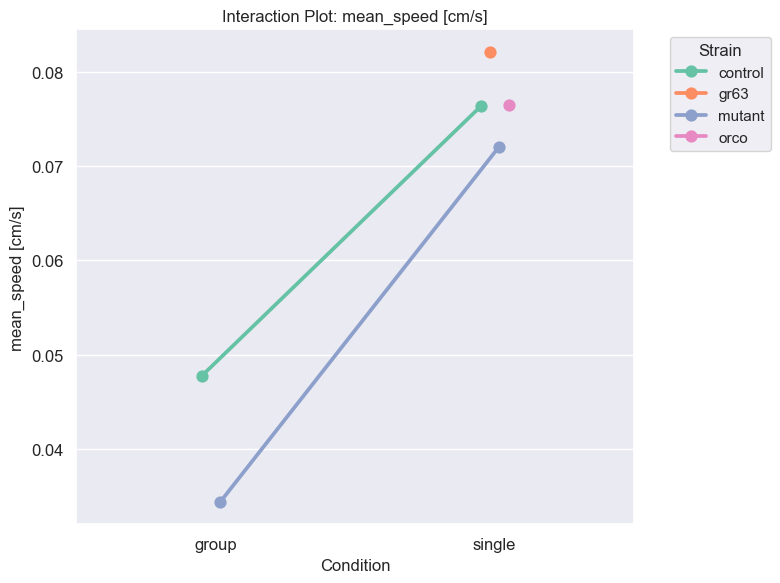

In [174]:
import matplotlib.pyplot as plt
import seaborn as sns

# 平均値と標準誤差を算出
summary_df = (
    all_df
    .groupby(['strain', 'condition'])['mean_speed [cm/s]']
    .agg(['mean', 'sem'])
    .reset_index()
)

# 図示
plt.figure(figsize=(8,6))
sns.pointplot(
    data=summary_df,
    x='condition', y='mean', hue='strain',
    dodge=True, join=True, markers='o', capsize=0.1, errwidth=1, palette='Set2'
)

plt.title("Interaction Plot: mean_speed [cm/s]")
plt.ylabel("mean_speed [cm/s]")
plt.xlabel("Condition")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Strain', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## double mutant vs control ANOVA

In [175]:
import pandas as pd

# 各DataFrameに group, condition 列を追加
def add_labels(df, strain, condition):
    df = df.copy()
    df["strain"] = strain
    df["condition"] = condition
    return df

dfs = [
    add_labels(control_single_results, "control", "single"),
    add_labels(control_group_results, "control", "group"),
    add_labels(mutant_single_results, "mutant", "single"),
    add_labels(mutant_group_results, "mutant", "group")
]

all_df = pd.concat(dfs, ignore_index=True)


In [176]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Q() で特殊文字を含むカラム名を囲む
model = ols('Q("mean_speed [cm/s]") ~ C(strain) * C(condition)', data=all_df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)


                          sum_sq    df           F        PR(>F)
C(strain)               0.001927   1.0   26.404082  2.128551e-06
C(condition)            0.020288   1.0  278.017229  6.106132e-27
C(strain):C(condition)  0.000383   1.0    5.252781  2.471913e-02
Residual                0.005473  75.0         NaN           NaN


In [177]:
# Tukeyの例（group列を使って）
all_df["group"] = all_df["strain"] + "_" + all_df["condition"]

from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(endog=all_df["mean_speed [cm/s]"], groups=all_df["group"], alpha=0.05)
print(tukey)

        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------
 control_group control_single   0.0285    0.0  0.0212  0.0358   True
 control_group   mutant_group  -0.0133    0.0 -0.0197 -0.0069   True
 control_group  mutant_single   0.0243    0.0  0.0169  0.0316   True
control_single   mutant_group  -0.0418    0.0 -0.0492 -0.0345   True
control_single  mutant_single  -0.0042 0.5269 -0.0124  0.0039  False
  mutant_group  mutant_single   0.0376    0.0  0.0302   0.045   True
--------------------------------------------------------------------


/tmp/ipykernel_100/717354194.py:14: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(
/tmp/ipykernel_100/717354194.py:14: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.pointplot(


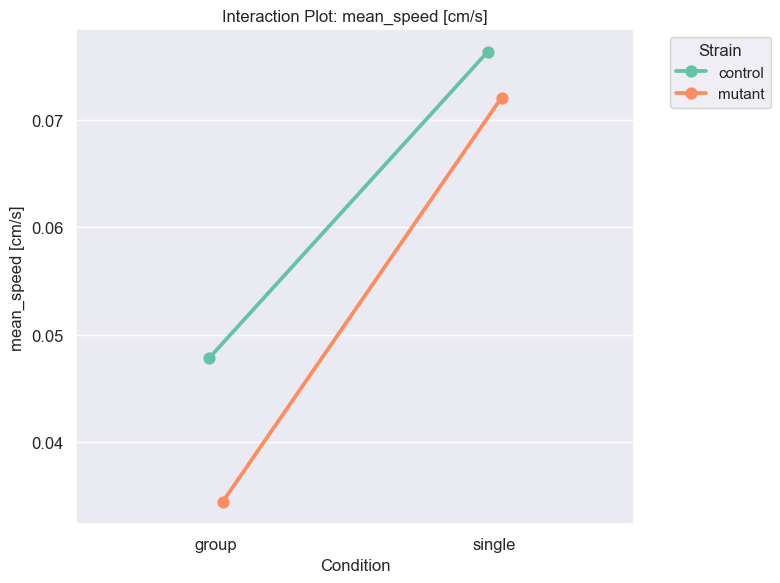

In [178]:
import matplotlib.pyplot as plt
import seaborn as sns

# 平均値と標準誤差を算出
summary_df = (
    all_df
    .groupby(['strain', 'condition'])['mean_speed [cm/s]']
    .agg(['mean', 'sem'])
    .reset_index()
)

# 図示
plt.figure(figsize=(8,6))
sns.pointplot(
    data=summary_df,
    x='condition', y='mean', hue='strain',
    dodge=True, join=True, markers='o', capsize=0.1, errwidth=1, palette='Set2'
)

plt.title("Interaction Plot: mean_speed [cm/s]")
plt.ylabel("mean_speed [cm/s]")
plt.xlabel("Condition")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Strain', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 結果の解釈

ありがとうございます。
これはおそらく **対象を「control」と「mutant（二重変異体）」のみに絞って、行動条件（single vs group）との交互作用を二要因ANOVAで検定し、Tukeyでペア比較を行った結果**ですね。

以下、**ANOVA結果**と**Tukeyの比較結果**を順に丁寧に解釈します。

---

## ✅ ANOVA 結果の解釈

| 要因                          | F値     | p値           | 解釈                           |
| --------------------------- | ------ | ------------ | ---------------------------- |
| **C(strain)**               | 26.40  | **2.13e-06** | Control と mutant で速度が異なる（有意） |
| **C(condition)**            | 278.02 | **6.11e-27** | 単独か集団かで速度が異なる（非常に有意）         |
| **C(strain)\:C(condition)** | 5.25   | **0.0247**   | **交互作用あり（有意）**               |

### 🔍 解釈まとめ：

* **変異の種類（control vs mutant）も**
* **行動条件（single vs group）も**
* **そしてその組み合わせの相互作用もすべて有意**である。

➡️ **mutant は control に比べ、行動条件による影響を受け方が異なる（interaction）**

---

## ✅ Tukey HSD（ペアごとの差の有無）

### 対象群：

* `control_group`
* `control_single`
* `mutant_group`
* `mutant_single`

| 比較                                    | 有意差 | 解釈例                                    |
| ------------------------------------- | --- | -------------------------------------- |
| **control\_group vs control\_single** | ✅   | control は **集団になると速くなる（+0.0285）**      |
| **control\_group vs mutant\_group**   | ✅   | mutant\_group は **遅い（-0.0133）**        |
| **control\_group vs mutant\_single**  | ✅   | mutant\_single も control より遅い（-0.0243） |
| **control\_single vs mutant\_group**  | ✅   | **mutant\_group が特に遅い（-0.0418）**       |
| control\_single vs mutant\_single     | ❌   | 差なし（-0.0042）                           |
| **mutant\_group vs mutant\_single**   | ✅   | mutant は **集団になるとかなり遅くなる（+0.0376）**    |

---

## ✅ 総合的な解釈

| ポイント                                | 解釈                                       |
| ----------------------------------- | ---------------------------------------- |
| ✅ **交互作用が有意**                       | mutant では **集団になると著しく遅くなる** ＝ 協調行動の破綻を示唆 |
| ✅ control では**集団の方が速い**             | 正常な集団行動が促進されている                          |
| ❌ mutant\_single vs control\_single | 有意差なし → mutant の異常は **集団条件で顕在化**         |

---

## ✅ 結論（論文化できる視点）

> 「二重変異体では集団下での移動速度が著しく低下しており、これは正常な社会的行動に必要な感覚入力や統合機構が損なわれている可能性を示唆する。一方で、単独行動では有意な差が見られなかったことから、mutantの異常は**環境依存的に顕在化**する社会性特異的な行動障害である可能性がある。」


# 多種認識について mel-wil group

In [215]:
other_group_dfs = glob.glob('../csvs/trajectory/mel-wil_*_overfit.csv')

other_group_df = pd.DataFrame()
other_group_results = pd.DataFrame()
for pathname in tqdm(other_group_dfs):
    filename = os.path.splitext(os.path.basename(pathname))[0]
    df = pd.read_csv(pathname)
    for ID_ in df['ID'].unique():
        df_ext = df[df['ID'] == ID_]
        _,_,pro_df = preprocess_trace_median_spline(df_ext, median_kernel=5, filename=filename)
        results = extract_features(pro_df, filename = filename, fps = 10, pixel2cm=single_pixel)
        other_group_df = pd.concat([other_group_df, pro_df])
        other_group_results = pd.concat([other_group_results, results])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 17.84it/s]


/tmp/ipykernel_100/56658150.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y=metric, data=subset, palette="coolwarm", ax=ax, showfliers=False)
/tmp/ipykernel_100/56658150.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='group', y=metric, data=subset, palette='coolwarm', linewidth=2, size=20, jitter=True, ax=ax)
/tmp/ipykernel_100/56658150.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y=metric, data=subset, palette="coolwarm", ax=ax, showfliers=False)
/tmp/ipykernel_100/56658150.py:26: FutureWarning

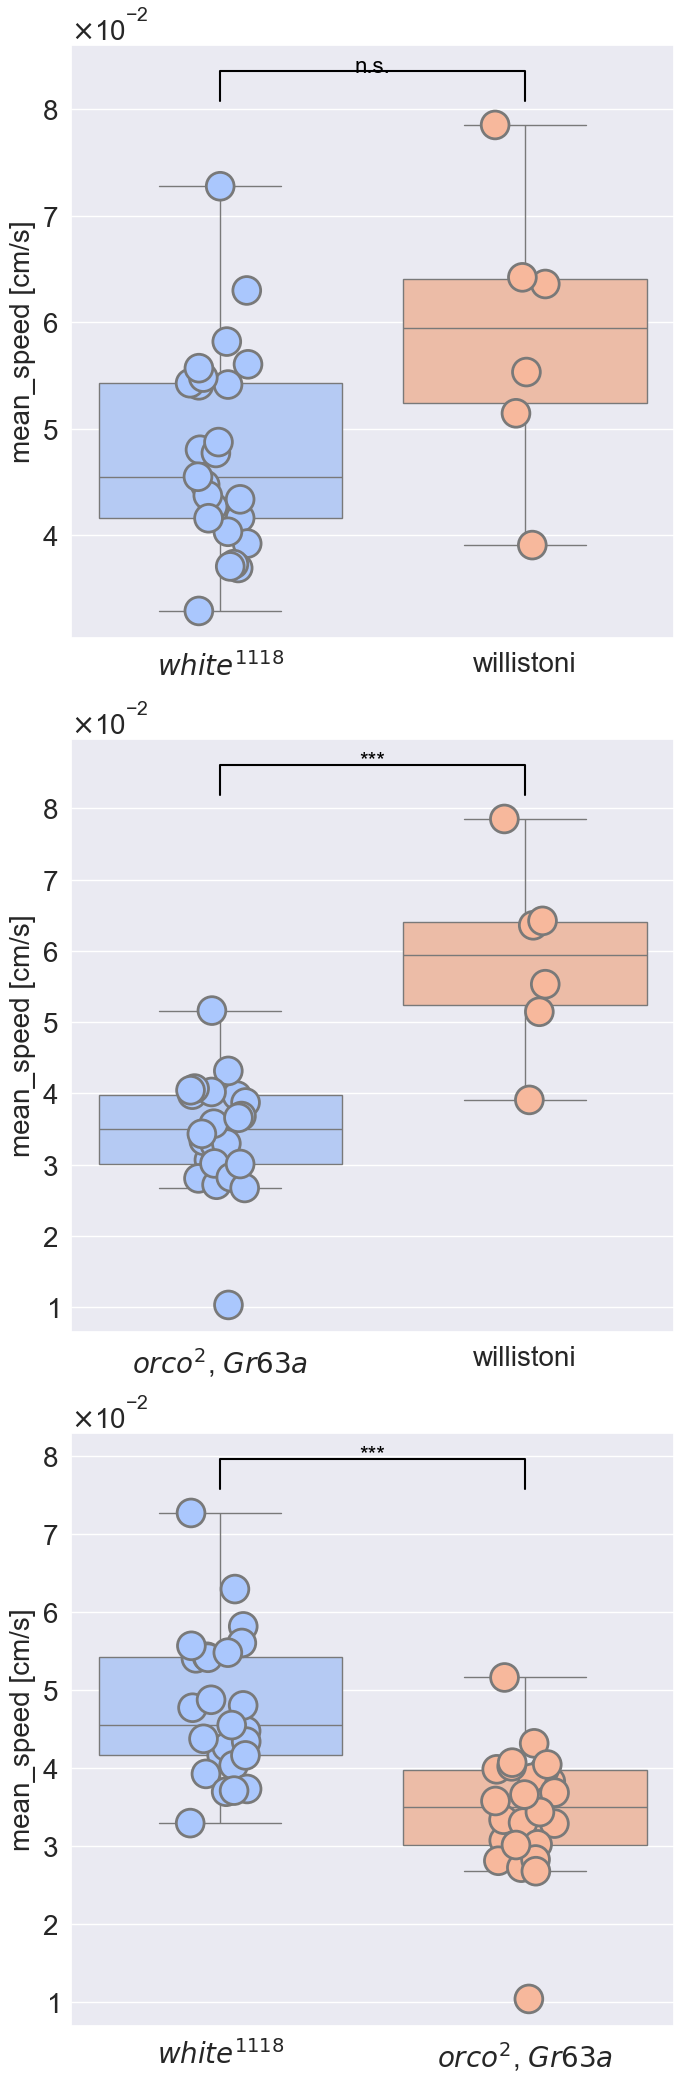

In [217]:
from scipy.stats import mannwhitneyu

# control_single_df と mutant_single_df を統合
all_results = pd.concat([control_group_results, mutant_group_results, other_group_results], ignore_index=True)

# 可視化したい指標リスト
metrics = feature_columns  # 例: ["total_dist", "mean_speed", "median_speed", "max_speed", "tortuosity"]

metrics = ["mean_speed [cm/s]"]

comparisons = [
    ("willistoni", "$white^{1118}$"),
    ("willistoni", "$orco^2$, $Gr63a$"),
    ("$white^{1118}$", "$orco^2$, $Gr63a$")  # 既存
]

fig, axes = plt.subplots(len(comparisons), len(metrics), figsize=(7 * len(metrics), 7 * len(comparisons)), squeeze=False)

for row_idx, (ctrl_group, mut_group) in enumerate(comparisons):
    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        # 対象グループのみ抽出
        subset = all_results[all_results['group'].isin([ctrl_group, mut_group])]

        sns.boxplot(x='group', y=metric, data=subset, palette="coolwarm", ax=ax, showfliers=False)
        sns.stripplot(x='group', y=metric, data=subset, palette='coolwarm', linewidth=2, size=20, jitter=True, ax=ax)


        # 軸フォーマット
        formatter = ticker.ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((0, 0))
        ax.yaxis.set_major_formatter(formatter)
        ax.yaxis.offsetText.set_fontsize(20)
        ax.tick_params(axis='x', labelsize=20)
        ax.tick_params(axis='y', labelsize=20)
        ax.set_ylabel(metric, fontsize=20)  # ← フォントサイズ指定
        ax.set_xlabel('')

        # p値計算とアノテーション
        ctrl_vals = subset[subset['group'] == ctrl_group][metric].dropna()
        mut_vals  = subset[subset['group'] == mut_group][metric].dropna()
        stat, p_val = mannwhitneyu(ctrl_vals, mut_vals, alternative='two-sided')
        y_max = subset[metric].max()
        y_min = subset[metric].min()
        h_offset = (y_max - y_min) * 0.05
        add_stat_annotation(ax, 0, 1, y_max + h_offset, p_val, h_offset)

plt.tight_layout()
#plt.suptitle("Single comparisons", fontsize=20)
plt.show()